In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots 
plt.style.use(["science", "grid"])
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "figure.titlesize": 15,
})

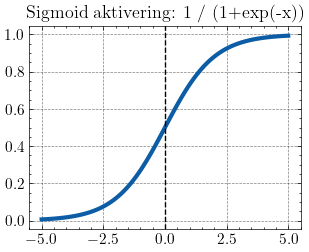

In [10]:
def sigmoid(x):
    return 1 / (1+np.exp(-x))
x = np.linspace(-5.0, 5.0, 100)
y = sigmoid(x)
plt.plot(x, y, lw='3')
plt.title("Sigmoid aktivering: 1 / (1+exp(-x))")
plt.axvline(0, ls='--', color='black', lw='1.0')
plt.show()

In [11]:
# definer funktion (netværk) med et lag (shallow network)

def shallow_network(x, W1, b1, W2, b2):

    # tjek dimensioner er som forventede
    assert W1.shape[1] == len(x) # samme antal x'ere som W1's kolonner
    assert W2.shape[1] == W1.shape[0] # W1@x spytter W1.shape[0]-dimensioner ud. tjek at W2 har dette antal kolonner.

    # hidden layer 
    a1 = W1 @ x + b1
    z1 = sigmoid(a1)

    # output layer
    a2 = W2 @ z1 + b2
    z2 = sigmoid(a2)
    
    return z2

In [12]:
x = np.array(
    [1.0, 2.0, 3.0]
)

W1 = np.array(
    [[0.5, 0.6, 0.7],
     [0.8, 0.9, 1.0],
     [1.1, 1.2, 1.3],
     [1.4, 1.5, 1.6],]
)
b1 = -2.0

W2 = np.array(
    [[2.1, 2.5, 2.8, 3.1]]
)
b2 = -1.5

shallow_network(x, W1, b1, W2, b2)

array([0.9998197])

Predicted probabilities:
[[0.001 0.999 0.999 0.001]]

Predicted classes:
[[0 1 1 0]]

True classes:
[[0 1 1 0]]


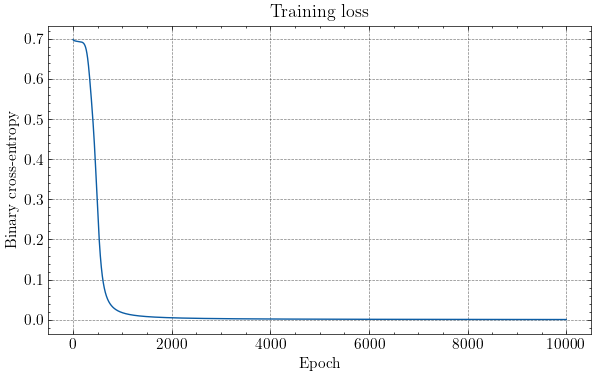

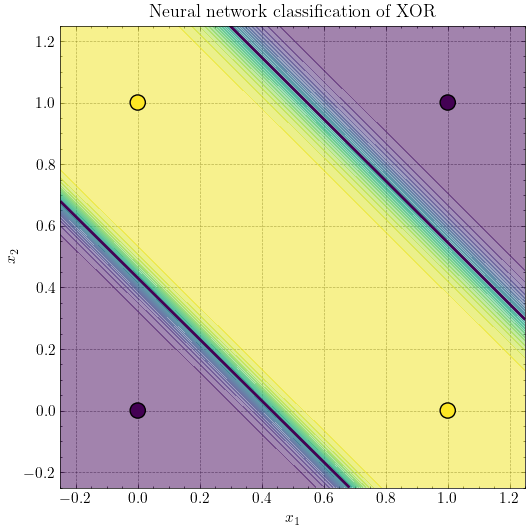

In [13]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Activation function
# ============================================================

def sigmoid(a):
    return 1 / (1 + np.exp(-a))


def sigmoid_prime(a):
    s = sigmoid(a)
    return s * (1 - s)



# ============================================================
# 3. Forward + backpropagation
# ============================================================

def backprop(X, y, W1, b1, W2, b2):

    N = X.shape[1]  # number of observations

    # --------------------------------------------------------
    # Forward propagation
    # --------------------------------------------------------

    a1 = W1 @ X + b1
    z1 = sigmoid(a1)

    a2 = W2 @ z1 + b2
    z2 = sigmoid(a2)


    # --------------------------------------------------------
    # Backpropagation
    # --------------------------------------------------------

    # Output layer
    #
    # With sigmoid + binary cross entropy:
    #
    # dL/da2 = z2 - y
    #
    delta2 = z2 - y


    # derivatives wrt W2 and b2
    dW2 = (delta2 @ z1.T) / N

    db2 = np.sum(
        delta2,
        axis=1,
        keepdims=True
    ) / N


    # Hidden layer
    #
    # dL/da1
    #
    delta1 = (W2.T @ delta2) * sigmoid_prime(a1)


    # derivatives wrt W1 and b1
    dW1 = (delta1 @ X.T) / N

    db1 = np.sum(
        delta1,
        axis=1,
        keepdims=True
    ) / N


    return dW1, db1, dW2, db2, z2


# ============================================================
# 4. Binary cross-entropy loss
# ============================================================

def binary_cross_entropy(y, y_hat):

    eps = 1e-12

    y_hat = np.clip(
        y_hat,
        eps,
        1 - eps
    )

    return -np.mean(
        y * np.log(y_hat)
        + (1 - y) * np.log(1 - y_hat)
    )


# ============================================================
# 5. Training function
# ============================================================

def train_network(
    X,
    y,
    n_hidden=4,
    learning_rate=1.0,
    epochs=10000,
    seed=42
):

    rng = np.random.default_rng(seed)

    n_inputs = X.shape[0]

    # --------------------------------------------------------
    # Initialize parameters
    # --------------------------------------------------------

    W1 = rng.normal(
        0,
        0.5,
        size=(n_hidden, n_inputs)
    )

    b1 = np.zeros(
        (n_hidden, 1)
    )

    W2 = rng.normal(
        0,
        0.5,
        size=(1, n_hidden)
    )

    b2 = np.zeros(
        (1, 1)
    )


    losses = []


    # --------------------------------------------------------
    # Gradient descent
    # --------------------------------------------------------

    for epoch in range(epochs):

        # calculate gradients using ALL observations
        dW1, db1, dW2, db2, y_hat = backprop(
            X,
            y,
            W1,
            b1,
            W2,
            b2
        )


        # gradient descent
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2


        # calculate loss
        loss = binary_cross_entropy(
            y,
            y_hat
        )

        losses.append(loss)


    return W1, b1, W2, b2, losses


# ============================================================
# 6. XOR DATA
# ============================================================

# Each COLUMN is one observation
#
#       obs1 obs2 obs3 obs4

X = np.array([
    [0,   0,   1,   1],
    [0,   1,   0,   1]
], dtype=float)


y = np.array([
    [0,   1,   1,   0]
], dtype=float)


# ============================================================
# 7. Train network
# ============================================================

W1, b1, W2, b2, losses = train_network(
    X,
    y,
    n_hidden=4,
    learning_rate=1.0,
    epochs=10000,
    seed=42
)


# ============================================================
# 8. Predictions
# ============================================================

y_hat = shallow_network(
    X,
    W1,
    b1,
    W2,
    b2
)


print("Predicted probabilities:")
print(np.round(y_hat, 3))

print("\nPredicted classes:")
print((y_hat > 0.5).astype(int))

print("\nTrue classes:")
print(y.astype(int))


# ============================================================
# 9. Plot training loss
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.title("Training loss")

plt.show()


# ============================================================
# 10. Plot learned XOR decision boundary
# ============================================================

x1_grid = np.linspace(-0.25, 1.25, 300)
x2_grid = np.linspace(-0.25, 1.25, 300)

xx1, xx2 = np.meshgrid(
    x1_grid,
    x2_grid
)

# grid points as columns, exactly like training data
X_grid = np.vstack([
    xx1.ravel(),
    xx2.ravel()
])

# neural network predictions
Z = shallow_network(
    X_grid,
    W1,
    b1,
    W2,
    b2
)

Z = Z.reshape(xx1.shape)


plt.figure(figsize=(6, 6))

# predicted probability surface
plt.contourf(
    xx1,
    xx2,
    Z,
    levels=30,
    alpha=0.5
)

# 0.5 classification boundary
plt.contour(
    xx1,
    xx2,
    Z,
    levels=[0.5],
    linewidths=2
)

# XOR observations
plt.scatter(
    X[0],
    X[1],
    c=y.ravel(),
    edgecolors="black",
    s=120
)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Neural network classification of XOR")

plt.xlim(-0.25, 1.25)
plt.ylim(-0.25, 1.25)

plt.show()

X shape: (784, 1877)
y shape: (1, 1877)
Epoch   0 | Train loss: 0.7050 | Test loss: 0.6955 | Train acc: 0.539 | Test acc: 0.545
Epoch  50 | Train loss: 0.0658 | Test loss: 0.1069 | Train acc: 0.981 | Test acc: 0.965
Epoch 100 | Train loss: 0.0465 | Test loss: 0.0943 | Train acc: 0.985 | Test acc: 0.968
Epoch 150 | Train loss: 0.0355 | Test loss: 0.0910 | Train acc: 0.989 | Test acc: 0.968
Epoch 200 | Train loss: 0.0282 | Test loss: 0.0919 | Train acc: 0.993 | Test acc: 0.965
Epoch 250 | Train loss: 0.0229 | Test loss: 0.0945 | Train acc: 0.994 | Test acc: 0.965
Epoch 300 | Train loss: 0.0191 | Test loss: 0.0977 | Train acc: 0.996 | Test acc: 0.965
Epoch 350 | Train loss: 0.0161 | Test loss: 0.1012 | Train acc: 0.997 | Test acc: 0.965
Epoch 400 | Train loss: 0.0138 | Test loss: 0.1048 | Train acc: 0.997 | Test acc: 0.965
Epoch 450 | Train loss: 0.0119 | Test loss: 0.1085 | Train acc: 0.997 | Test acc: 0.965

Final results
-----------------------------
Training accuracy: 99.87%
Test accu

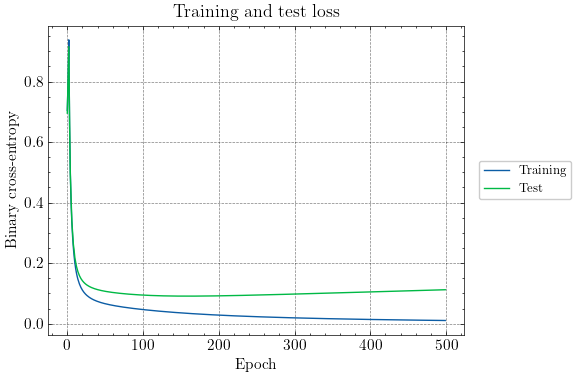

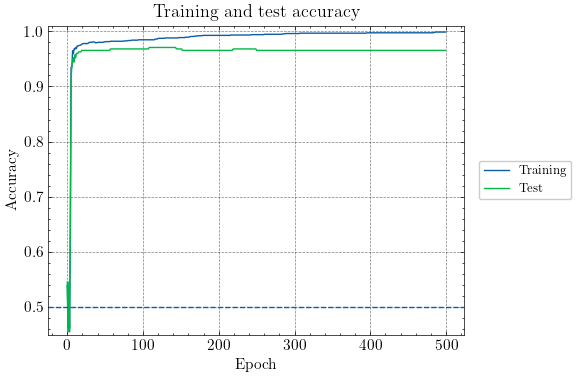


Misclassified test observations: 13 / 376


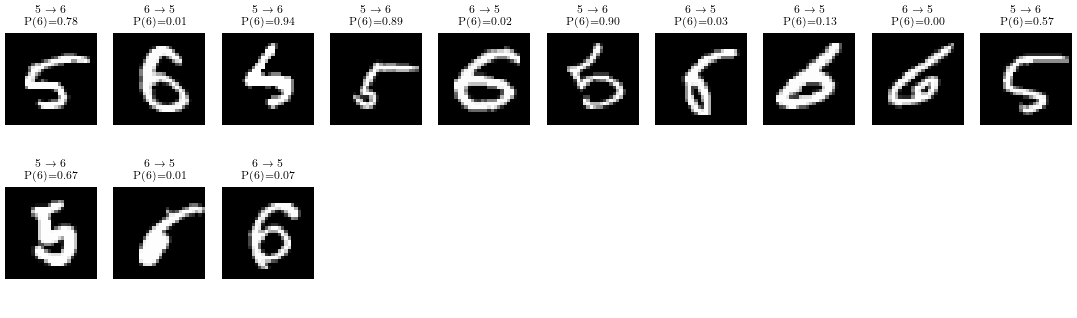

In [14]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD DATA
# ============================================================

pixels = np.loadtxt(
    r"C:\Users\caspe\OneDrive - University of Copenhagen\Kandidat\7_semester\MLA_DIKU\hw_assignments\HA1\data\MNIST-5-6-Subset.txt"
)

labels = np.loadtxt(
    r"C:\Users\caspe\OneDrive - University of Copenhagen\Kandidat\7_semester\MLA_DIKU\hw_assignments\HA1\data\MNIST-5-6-Subset-Labels.txt"
)

# Each column is one observation/image
X = pixels.reshape(784, 1877, order="F").astype(float)

# Normalize pixels to [0,1]
if X.max() > 1:
    X = X / 255.0

# Map 5 -> 0 and 6 -> 1
y = np.where(labels == 5, 0, 1).reshape(1, -1)

print("X shape:", X.shape)
print("y shape:", y.shape)


# ============================================================
# 2. TRAIN / TEST SPLIT
# ============================================================

rng = np.random.default_rng(42)

N = X.shape[1]

indices = rng.permutation(N)

N_train = int(0.8 * N)

train_idx = indices[:N_train]
test_idx = indices[N_train:]

X_train = X[:, train_idx]
y_train = y[:, train_idx]

X_test = X[:, test_idx]
y_test = y[:, test_idx]


# ============================================================
# 3. ACTIVATION FUNCTIONS
# ============================================================

def sigmoid(a):
    return 1 / (1 + np.exp(-a))


def sigmoid_prime(a):
    s = sigmoid(a)
    return s * (1 - s)


# ============================================================
# 4. SHALLOW NEURAL NETWORK
# ============================================================

def shallow_network(X, W1, b1, W2, b2):

    # Hidden layer
    a1 = W1 @ X + b1
    z1 = sigmoid(a1)

    # Output layer
    a2 = W2 @ z1 + b2
    z2 = sigmoid(a2)

    return z2


# ============================================================
# 5. BACKPROPAGATION
# ============================================================

def backprop(X, y, W1, b1, W2, b2):

    N = X.shape[1]

    # --------------------------------------------------------
    # Forward pass
    # --------------------------------------------------------

    a1 = W1 @ X + b1
    z1 = sigmoid(a1)

    a2 = W2 @ z1 + b2
    z2 = sigmoid(a2)


    # --------------------------------------------------------
    # Backward pass
    # --------------------------------------------------------

    # Sigmoid output + binary cross entropy:
    # dL / da2 = z2 - y
    delta2 = z2 - y

    # Output layer gradients
    dW2 = (delta2 @ z1.T) / N
    db2 = np.mean(delta2, axis=1, keepdims=True)

    # Propagate error to hidden layer
    delta1 = (W2.T @ delta2) * sigmoid_prime(a1)

    # Hidden layer gradients
    dW1 = (delta1 @ X.T) / N
    db1 = np.mean(delta1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2


# ============================================================
# 6. LOSS + ACCURACY
# ============================================================

def binary_cross_entropy(y, y_hat):

    eps = 1e-12

    y_hat = np.clip(y_hat, eps, 1 - eps)

    return -np.mean(
        y * np.log(y_hat)
        + (1 - y) * np.log(1 - y_hat)
    )


def accuracy(y, y_hat):

    y_pred = (y_hat >= 0.5).astype(int)

    return np.mean(y_pred == y)


# ============================================================
# 7. INITIALIZE NETWORK
# ============================================================

rng = np.random.default_rng(42)

n_inputs = 784
n_hidden = 32
n_output = 1

W1 = rng.normal(
    0,
    np.sqrt(1 / n_inputs),
    size=(n_hidden, n_inputs)
)

b1 = np.zeros((n_hidden, 1))

W2 = rng.normal(
    0,
    np.sqrt(1 / n_hidden),
    size=(n_output, n_hidden)
)

b2 = np.zeros((n_output, 1))


# ============================================================
# 8. TRAIN NETWORK
# ============================================================

epochs = 500
learning_rate = 1.0

train_losses = []
test_losses = []

train_accuracies = []
test_accuracies = []


for epoch in range(epochs):

    # Calculate gradients using ALL training observations
    dW1, db1, dW2, db2 = backprop(
        X_train,
        y_train,
        W1,
        b1,
        W2,
        b2
    )

    # Gradient descent
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    # Predictions
    y_hat_train = shallow_network(
        X_train,
        W1,
        b1,
        W2,
        b2
    )

    y_hat_test = shallow_network(
        X_test,
        W1,
        b1,
        W2,
        b2
    )

    # Save loss
    train_losses.append(
        binary_cross_entropy(y_train, y_hat_train)
    )

    test_losses.append(
        binary_cross_entropy(y_test, y_hat_test)
    )

    # Save accuracy
    train_accuracies.append(
        accuracy(y_train, y_hat_train)
    )

    test_accuracies.append(
        accuracy(y_test, y_hat_test)
    )

    if epoch % 50 == 0:

        print(
            f"Epoch {epoch:3d} | "
            f"Train loss: {train_losses[-1]:.4f} | "
            f"Test loss: {test_losses[-1]:.4f} | "
            f"Train acc: {train_accuracies[-1]:.3f} | "
            f"Test acc: {test_accuracies[-1]:.3f}"
        )


# ============================================================
# 9. FINAL PERFORMANCE
# ============================================================

y_hat_train = shallow_network(
    X_train,
    W1,
    b1,
    W2,
    b2
)

y_hat_test = shallow_network(
    X_test,
    W1,
    b1,
    W2,
    b2
)

train_acc = accuracy(y_train, y_hat_train)
test_acc = accuracy(y_test, y_hat_test)

print("\nFinal results")
print("-----------------------------")
print(f"Training accuracy: {100 * train_acc:.2f}%")
print(f"Test accuracy:     {100 * test_acc:.2f}%")
print(f"Test error:        {100 * (1 - test_acc):.2f}%")


# ============================================================
# 10. PLOT LOSS
# ============================================================

plt.figure(figsize=(6, 4))

plt.plot(
    train_losses,
    label="Training"
)

plt.plot(
    test_losses,
    label="Test"
)

plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.title("Training and test loss")

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.show()


# ============================================================
# 11. PLOT ACCURACY
# ============================================================

plt.figure(figsize=(6, 4))

plt.plot(
    train_accuracies,
    label="Training"
)

plt.plot(
    test_accuracies,
    label="Test"
)

plt.axhline(
    y=0.5,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and test accuracy")

plt.ylim(0.45, 1.01)

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.show()


# ============================================================
# 12. SHOW MISCLASSIFIED TEST IMAGES
# ============================================================

y_pred_test = (y_hat_test >= 0.5).astype(int)

wrong = np.where(
    y_pred_test.ravel() != y_test.ravel()
)[0]

print(
    f"\nMisclassified test observations: "
    f"{len(wrong)} / {X_test.shape[1]}"
)

n_show = min(20, len(wrong))

if n_show > 0:

    fig, axes = plt.subplots(
        2,
        10,
        figsize=(11, 3.5)
    )

    axes = axes.ravel()

    for ax in axes:
        ax.axis("off")

    for ax, i in zip(axes, wrong[:n_show]):

        image = X_test[:, i].reshape(
            28,
            28,
            order="F"
        )

        true_digit = (
            5 if y_test[0, i] == 0 else 6
        )

        predicted_digit = (
            5 if y_pred_test[0, i] == 0 else 6
        )

        probability_6 = y_hat_test[0, i]

        ax.imshow(
            image,
            cmap="gray"
        )

        ax.set_title(
            f"{true_digit} → {predicted_digit}\n"
            f"P(6)={probability_6:.2f}",
            fontsize=8
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

Training network with 1 hidden neurons...
Train accuracy: 99.93% | Test accuracy: 96.28%

Training network with 2 hidden neurons...
Train accuracy: 99.87% | Test accuracy: 96.01%

Training network with 4 hidden neurons...
Train accuracy: 99.87% | Test accuracy: 96.54%

Training network with 8 hidden neurons...
Train accuracy: 99.93% | Test accuracy: 96.54%

Training network with 16 hidden neurons...
Train accuracy: 99.93% | Test accuracy: 96.54%

Training network with 32 hidden neurons...
Train accuracy: 99.87% | Test accuracy: 96.54%

Training network with 64 hidden neurons...
Train accuracy: 99.87% | Test accuracy: 96.81%

Training network with 128 hidden neurons...
Train accuracy: 99.87% | Test accuracy: 96.81%


Results
-------------------------------------------------
Hidden neurons | Train accuracy | Test accuracy
-------------------------------------------------
             1 |         99.93% |        96.28%
             2 |         99.87% |        96.01%
             4 |      

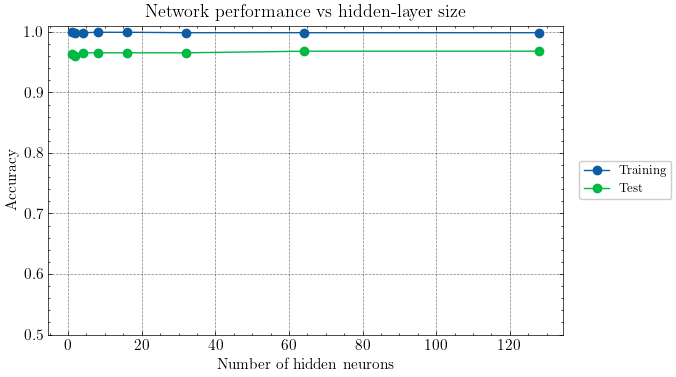

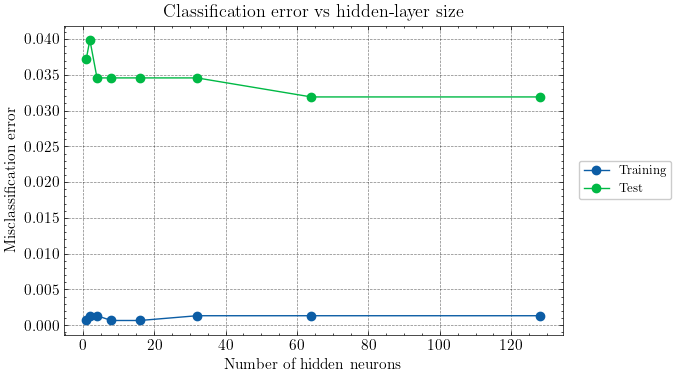


Best test performance: 96.81% with 64 hidden neurons.


In [15]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Train network for a given number of hidden neurons
# ============================================================

def train_network(
    X_train,
    y_train,
    X_test,
    y_test,
    n_hidden,
    epochs=500,
    learning_rate=1.0,
    seed=42
):

    rng = np.random.default_rng(seed)

    n_inputs = X_train.shape[0]
    n_output = 1


    # --------------------------------------------------------
    # Initialize weights
    # --------------------------------------------------------

    W1 = rng.normal(
        0,
        np.sqrt(1 / n_inputs),
        size=(n_hidden, n_inputs)
    )

    b1 = np.zeros((n_hidden, 1))

    W2 = rng.normal(
        0,
        np.sqrt(1 / n_hidden),
        size=(n_output, n_hidden)
    )

    b2 = np.zeros((n_output, 1))


    train_losses = []
    test_losses = []

    train_accuracies = []
    test_accuracies = []


    # --------------------------------------------------------
    # Gradient descent
    # --------------------------------------------------------

    for epoch in range(epochs):

        # gradients
        dW1, db1, dW2, db2 = backprop(
            X_train,
            y_train,
            W1,
            b1,
            W2,
            b2
        )


        # update parameters
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2


        # predictions
        y_hat_train = shallow_network(
            X_train,
            W1,
            b1,
            W2,
            b2
        )

        y_hat_test = shallow_network(
            X_test,
            W1,
            b1,
            W2,
            b2
        )


        # save loss
        train_losses.append(
            binary_cross_entropy(
                y_train,
                y_hat_train
            )
        )

        test_losses.append(
            binary_cross_entropy(
                y_test,
                y_hat_test
            )
        )


        # save accuracy
        train_accuracies.append(
            accuracy(
                y_train,
                y_hat_train
            )
        )

        test_accuracies.append(
            accuracy(
                y_test,
                y_hat_test
            )
        )


    return {
        "n_hidden": n_hidden,
        "W1": W1,
        "b1": b1,
        "W2": W2,
        "b2": b2,
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_accuracies": train_accuracies,
        "test_accuracies": test_accuracies,
        "train_accuracy": train_accuracies[-1],
        "test_accuracy": test_accuracies[-1]
    }


# ============================================================
# Try different numbers of hidden neurons
# ============================================================

hidden_sizes = [
    1,
    2,
    4,
    8,
    16,
    32,
    64,
    128
]

results = []


for n_hidden in hidden_sizes:

    print(f"Training network with {n_hidden} hidden neurons...")

    result = train_network(
        X_train,
        y_train,
        X_test,
        y_test,
        n_hidden=n_hidden,
        epochs=500,
        learning_rate=1.0,
        seed=42
    )

    results.append(result)

    print(
        f"Train accuracy: {100 * result['train_accuracy']:.2f}% | "
        f"Test accuracy: {100 * result['test_accuracy']:.2f}%"
    )

    print()


# ============================================================
# Extract final results
# ============================================================

train_accuracy = np.array([
    result["train_accuracy"]
    for result in results
])

test_accuracy = np.array([
    result["test_accuracy"]
    for result in results
])


train_error = 1 - train_accuracy
test_error = 1 - test_accuracy


# ============================================================
# Print table
# ============================================================

print("\nResults")
print("-------------------------------------------------")
print("Hidden neurons | Train accuracy | Test accuracy")
print("-------------------------------------------------")


for n_hidden, train_acc, test_acc in zip(
    hidden_sizes,
    train_accuracy,
    test_accuracy
):

    print(
        f"{n_hidden:14d} | "
        f"{100 * train_acc:13.2f}% | "
        f"{100 * test_acc:12.2f}%"
    )


# ============================================================
# Plot accuracy vs number of hidden neurons
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(
    hidden_sizes,
    train_accuracy,
    marker="o",
    label="Training"
)

plt.plot(
    hidden_sizes,
    test_accuracy,
    marker="o",
    label="Test"
)

plt.xlabel("Number of hidden neurons")
plt.ylabel("Accuracy")
plt.title("Network performance vs hidden-layer size")

plt.ylim(0.5, 1.01)

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.show()


# ============================================================
# Plot error vs number of hidden neurons
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(
    hidden_sizes,
    train_error,
    marker="o",
    label="Training"
)

plt.plot(
    hidden_sizes,
    test_error,
    marker="o",
    label="Test"
)

plt.xlabel("Number of hidden neurons")
plt.ylabel("Misclassification error")
plt.title("Classification error vs hidden-layer size")

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.show()


# ============================================================
# Find best hidden-layer size according to TEST accuracy
# ============================================================

best_index = np.argmax(test_accuracy)

best_hidden = hidden_sizes[best_index]

print(
    f"\nBest test performance: "
    f"{100 * test_accuracy[best_index]:.2f}% "
    f"with {best_hidden} hidden neurons."
)